# Compare MC Corrections — multi-file overlay

Loads `hMcCorrectionP`, `hMcCorrectionM`, `hMcCorrectionP_fit`, `hMcCorrectionM_fit` from
several `*_fit.root` files and overlays them at user-selected (xB, Q², z) bins.

**Plot modes**
- `vs_z`  : grid of (xB, Q²) panels → w vs z, one curve per file
- `vs_q2` : grid of xB panels         → w vs Q², one curve per file (at selected z bin)
- `vs_xB` : grid of Q² panels         → w vs xB, one curve per file (at selected z bin)

In [217]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import math

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
#
# Each entry: (path_to_fit_root_file, short_label)
# The first file's raw histogram (hMcCorrectionP/M) is used for data points.
# All files provide fit histograms (hMcCorrectionP/M_fit).

FILES = [
    ('../data/correctionFiles/corrections_10.2_AN_fit.root',    'RGB 10.2'),
    ('../data/correctionFiles/corrections_10.4_AN_fit.root',    'RGB 10.4'),
    ('../data/correctionFiles/corrections_10.6_AN_fit.root',    'RGB 10.6'),
    #('../data/correctionFiles/corrections_10.4_fit.root',    'RGB 10.4'),
    #('../data/correctionFiles/corrections_10.6_fit.root',    'RGB 10.6'),
    #('../data/correctionFiles/corrections_10.2_rga_fit.root','RGA 10.2'),
    #('../data/correctionFiles/corrections_10.2_10637_fit.root',    '10637'),
    #('../data/correctionFiles/corrections_10.6_10820_fit.root',    '10820'), 
    #('../data/correctionFiles/corrections_10.6_AN_fit.root',    'AN'),   
  
    #('../data/correctionFiles/corrections_10.4_10892_fit.root',    '10892'),


    #('../data/correctionFiles/corrections_rga_10637_fit.root',    'RGA 10.2 New'),


]

# ── Plot mode ─────────────────────────────────────────────────────────────────
MODE = 'vs_q2'   # 'vs_z' | 'vs_q2' | 'vs_xB'

# ── Which bins to display ─────────────────────────────────────────────────────
# None = all bins.  List of 0-based indices to restrict.
SHOW_XB_BINS = [4, 5, 8, 11]   # None for all 14
SHOW_Q2_BINS = [3, 4, 7, 10]   # None for all 12
SHOW_Z_BIN   = 4               # scalar index used in vs_q2 and vs_xB modes

# Show raw data points from each file (True), or only from the first file (False)
SHOW_DATA_ALL = False

# Y-axis limits
Y_LIM = (0.5, 6.0)

# Output directory (None = display inline)
OUT_DIR = None

In [219]:
# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'font.family':       'sans-serif',
})

_cmap      = mcm.get_cmap('tab10')
FILE_COLORS = [_cmap(i / 10) for i in range(10)]

LINESTYLES = ['-', '--', ':', '-.']
MARKERS    = ['o', 's', '^', 'D', 'v', '<']

LABEL = {'xB': r'$x_B$', 'Q2': r'$Q^2\;[\mathrm{GeV}^2]$', 'z': r'$z$'}

def panel_label(ax, text):
    ax.text(0.96, 0.96, text, transform=ax.transAxes, ha='right', va='top',
            fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#aaaaaa', alpha=0.85))

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_28997/1746237135.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap      = mcm.get_cmap('tab10')


In [220]:
# ── Load histograms from all files ────────────────────────────────────────────

def _load_file(path):
    """Return dict with arrays for P and M, raw and fit."""
    with uproot.open(path) as f:
        hP     = f['hMcCorrectionP']
        hM     = f['hMcCorrectionM']
        hP_fit = f['hMcCorrectionP_fit']
        hM_fit = f['hMcCorrectionM_fit']

        # Bin edges from first file only (assumed identical across files)
        edges = {
            'xB': hP.axes[0].edges(),
            'Q2': hP.axes[1].edges(),
            'z':  hP.axes[2].edges(),
        }

        def _arr(h):
            v = h.values().copy()
            e = np.sqrt(h.variances())
            bad = ~(np.isfinite(v) & (v > 0) & np.isfinite(e))
            v[bad] = np.nan;  e[bad] = np.nan
            return v, e

        return {
            'edges':    edges,
            'vals_P':   _arr(hP),
            'vals_M':   _arr(hM),
            'fit_P':    _arr(hP_fit),
            'fit_M':    _arr(hM_fit),
        }


print('Loading files...')
datasets = []
for path, label in FILES:
    try:
        d = _load_file(path)
        d['label'] = label
        d['path']  = path
        datasets.append(d)
        print(f'  OK  {label:20s}  {path}')
    except Exception as exc:
        print(f'  SKIP {label}: {exc}')

assert datasets, 'No files loaded — check FILES configuration.'

# Reference bin edges (from first loaded file)
edges     = datasets[0]['edges']
xB_edges  = edges['xB']
Q2_edges  = edges['Q2']
z_edges   = edges['z']
xB_centers = 0.5 * (xB_edges[:-1] + xB_edges[1:])
Q2_centers = 0.5 * (Q2_edges[:-1] + Q2_edges[1:])
z_centers  = 0.5 * (z_edges[:-1]  + z_edges[1:])
n_xB = len(xB_centers)
n_Q2 = len(Q2_centers)
n_z  = len(z_centers)

# Resolved bin index lists
ix_list = list(range(n_xB)) if SHOW_XB_BINS is None else SHOW_XB_BINS
iq_list = list(range(n_Q2)) if SHOW_Q2_BINS is None else SHOW_Q2_BINS

print(f'\nBin grid: xB={n_xB}, Q2={n_Q2}, z={n_z}')
print(f'Displaying: xB bins={ix_list}, Q2 bins={iq_list}')

Loading files...
  OK  RGB 10.2              ../data/correctionFiles/corrections_10.6_fit.root
  SKIP 10820: [Errno 2] No such file or directory: '/Users/jasonphelan/Documents/Work/sidis_analysis_suite/plotting/../data/correctionFiles/corrections_10.6_10820_fit.root'
  SKIP AN: [Errno 2] No such file or directory: '/Users/jasonphelan/Documents/Work/sidis_analysis_suite/plotting/../data/correctionFiles/corrections_10.6_AN_fit.root'

Bin grid: xB=14, Q2=12, z=14
Displaying: xB bins=[4, 5, 8, 11], Q2 bins=[3, 4, 7, 10]


In [221]:
# ── Helper: xB / Q2 / z panel label strings ───────────────────────────────────
def xb_lbl(ix): return rf'${xB_edges[ix]:.2f} < x_B < {xB_edges[ix+1]:.2f}$'
def q2_lbl(iq): return rf'${Q2_edges[iq]:.1f} < Q^2 < {Q2_edges[iq+1]:.1f}$'
def z_lbl(iz):  return rf'${z_edges[iz]:.2f} < z < {z_edges[iz+1]:.2f}$'


# ── Helper: draw one 1-D comparison panel ─────────────────────────────────────
def _draw_panel(ax, x_vals, sign, ix, iq, iz_or_none, mode):
    """
    Draw data + fit curves for all loaded datasets onto ax.

    mode='vs_z'  : x_vals = z_centers,  fix (ix, iq)
    mode='vs_q2' : x_vals = Q2_centers, fix (ix, iz_or_none)
    mode='vs_xB' : x_vals = xB_centers, fix (iq, iz_or_none)
    sign = 'P' or 'M'
    """
    for fi, d in enumerate(datasets):
        color  = FILE_COLORS[fi % len(FILE_COLORS)]
        ls     = LINESTYLES[fi % len(LINESTYLES)]
        marker = MARKERS[fi % len(MARKERS)]

        # Pick the right slice
        if mode == 'vs_z':
            raw_v, raw_e = d[f'vals_{sign}'][0][ix, iq, :], d[f'vals_{sign}'][1][ix, iq, :]
            fit_v, fit_e = d[f'fit_{sign}'][0][ix, iq, :],  d[f'fit_{sign}'][1][ix, iq, :]
        elif mode == 'vs_q2':
            iz = iz_or_none
            raw_v, raw_e = d[f'vals_{sign}'][0][ix, :, iz], d[f'vals_{sign}'][1][ix, :, iz]
            fit_v, fit_e = d[f'fit_{sign}'][0][ix, :, iz],  d[f'fit_{sign}'][1][ix, :, iz]
        else:  # vs_xB
            iz = iz_or_none
            raw_v, raw_e = d[f'vals_{sign}'][0][:, iq, iz], d[f'vals_{sign}'][1][:, iq, iz]
            fit_v, fit_e = d[f'fit_{sign}'][0][:, iq, iz],  d[f'fit_{sign}'][1][:, iq, iz]

        # Raw data points (all files or first only)
        if fi == 0 or SHOW_DATA_ALL:
            mask_raw = np.isfinite(raw_v)
            ax.errorbar(x_vals[mask_raw], raw_v[mask_raw], raw_e[mask_raw],
                        fmt=marker, color=color, ms=3, lw=0, elinewidth=0.8,
                        capsize=1.5, alpha=0.6, zorder=3)

        # Fit curve
        mask_fit = np.isfinite(fit_v)
        if mask_fit.any():
            ax.plot(x_vals[mask_fit], fit_v[mask_fit],
                    color=color, lw=1.4, ls=ls, label=d['label'], zorder=4)
            ax.fill_between(x_vals,
                            np.where(mask_fit, fit_v - fit_e, np.nan),
                            np.where(mask_fit, fit_v + fit_e, np.nan),
                            color=color, alpha=0.12, zorder=2)

    ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
    ax.set_ylim(Y_LIM)

In [222]:
# ── Mode: vs_z  — grid of (xB, Q2) panels ─────────────────────────────────────
import os
if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

if MODE == 'vs_z':
    n_rows = len(ix_list)
    n_cols = len(iq_list)
    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 3.4, n_rows * 3.0),
        sharex=True, sharey=True, constrained_layout=True
    )
    if n_rows == 1 and n_cols == 1:
        axs = np.array([[axs]])
    elif n_rows == 1:
        axs = axs[np.newaxis, :]
    elif n_cols == 1:
        axs = axs[:, np.newaxis]

    for row, ix in enumerate(ix_list):
        for col, iq in enumerate(iq_list):
            ax = axs[row, col]

            # π⁺ solid, π⁻ dashed — different saturation via alpha
            # We'll put π⁺ and π⁻ on the same panel in different saturations;
            # file identity = color, charge = line style offset
            for fi, d in enumerate(datasets):
                color = FILE_COLORS[fi % len(FILE_COLORS)]
                for sign, ls, alpha_fill in [('P', '-', 0.12), ('M', '--', 0.06)]:
                    fit_v, fit_e = d[f'fit_{sign}'][0][ix, iq, :], d[f'fit_{sign}'][1][ix, iq, :]
                    mask = np.isfinite(fit_v)
                    if not mask.any():
                        continue
                    lbl = f"{d['label']} π{'⁺' if sign=='P' else '⁻'}"
                    ax.plot(z_centers[mask], fit_v[mask],
                            color=color, lw=1.4, ls=ls, label=lbl, zorder=4)
                    ax.fill_between(z_centers,
                                    np.where(mask, fit_v - fit_e, np.nan),
                                    np.where(mask, fit_v + fit_e, np.nan),
                                    color=color, alpha=alpha_fill, zorder=2)

            # Raw data from first file (π⁺ circles, π⁻ squares)
            for sign, mk in [('P', 'o'), ('M', 's')]:
                raw_v, raw_e = datasets[0][f'vals_{sign}'][0][ix, iq, :], \
                               datasets[0][f'vals_{sign}'][1][ix, iq, :]
                mask = np.isfinite(raw_v)
                ax.errorbar(z_centers[mask], raw_v[mask], raw_e[mask],
                            fmt=mk, color='#666666', ms=3, lw=0, elinewidth=0.8,
                            capsize=1.5, alpha=0.5, zorder=3)

            ax.axhline(1.0, color='#555', lw=0.8, ls='--', zorder=1)
            ax.set_ylim(Y_LIM)
            ax.set_xlim(z_edges[0], z_edges[-1])

            # Column header = Q2 label (top row only)
            if row == 0:
                ax.set_title(q2_lbl(iq), fontsize=8)
            # Row label = xB (right edge of leftmost column)
            if col == 0:
                ax.set_ylabel(r'$w$', fontsize=10)
                panel_label(ax, xb_lbl(ix))
            if row == n_rows - 1:
                ax.set_xlabel(LABEL['z'], fontsize=10)

    # Shared legend (file colors + π±)
    seen = {}; all_h = []; all_l = []
    for _ax in axs.ravel():
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=min(len(all_h), 6),
               fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.5)

    if OUT_DIR:
        fname = f'{OUT_DIR}/compare_vs_z.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'Saved {fname}')
    else:
        plt.show()

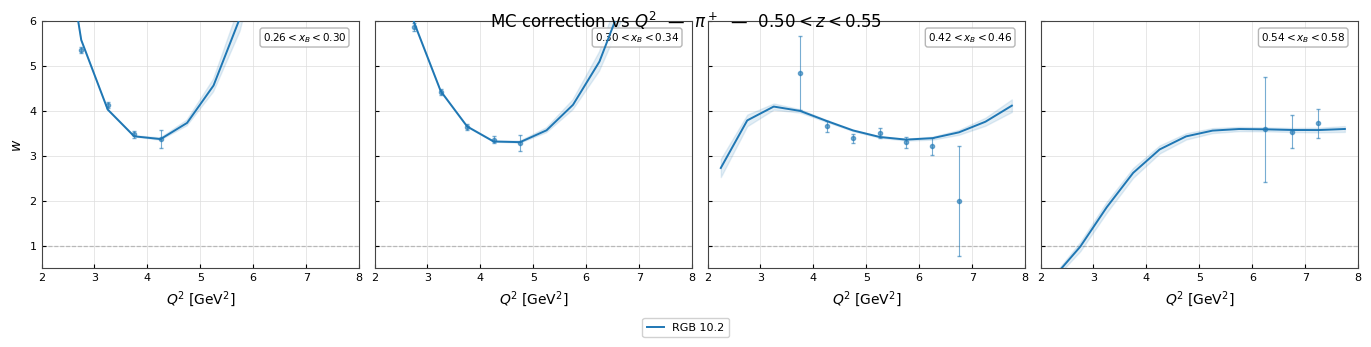

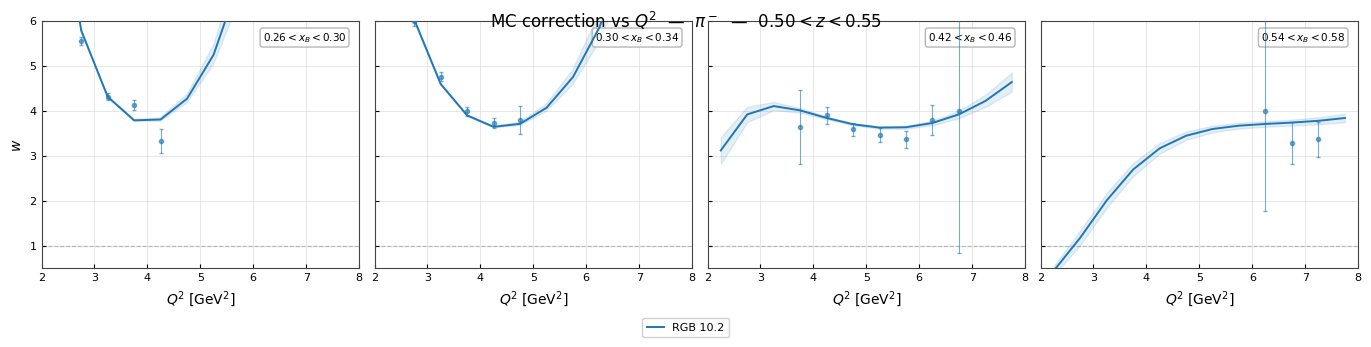

In [223]:
# ── Mode: vs_q2  — grid of xB panels, w vs Q2 at fixed z bin ─────────────────
if MODE == 'vs_q2':
    ncols = min(4, len(ix_list))
    nrows = math.ceil(len(ix_list) / ncols)

    for sign, sign_lbl in [('P', r'$\pi^+$'), ('M', r'$\pi^-$')]:
        fig, axs = plt.subplots(
            nrows, ncols, figsize=(ncols * 3.4, nrows * 3.0),
            sharex=True, sharey=True, constrained_layout=True
        )
        fig.suptitle(
            rf'MC correction vs $Q^2$  —  {sign_lbl}  —  {z_lbl(SHOW_Z_BIN)}',
            fontsize=12, y=1.01
        )
        axs_flat = np.array(axs).ravel()

        for pi, ix in enumerate(ix_list):
            ax = axs_flat[pi]
            panel_label(ax, xb_lbl(ix))
            _draw_panel(ax, Q2_centers, sign, ix, None, SHOW_Z_BIN, 'vs_q2')
            ax.set_xlim(Q2_edges[0], Q2_edges[-1])
            col = pi % ncols
            row = pi // ncols
            if col == 0:
                ax.set_ylabel(r'$w$', fontsize=10)
            if row == nrows - 1:
                ax.set_xlabel(LABEL['Q2'], fontsize=10)

        for pi in range(len(ix_list), nrows * ncols):
            axs_flat[pi].set_visible(False)

        seen = {}; all_h = []; all_l = []
        for _ax in axs_flat[:len(ix_list)]:
            for _h, _l in zip(*_ax.get_legend_handles_labels()):
                if _l not in seen:
                    seen[_l] = True; all_h.append(_h); all_l.append(_l)
        fig.legend(all_h, all_l, loc='upper center',
                   bbox_to_anchor=(0.5, 0.0), ncol=len(datasets),
                   fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.5)

        if OUT_DIR:
            fname = f'{OUT_DIR}/compare_vs_q2_{sign}.png'
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f'Saved {fname}')
        else:
            plt.show()

In [224]:
# ── Mode: vs_xB  — grid of Q2 panels, w vs xB at fixed z bin ─────────────────
if MODE == 'vs_xB':
    ncols = min(4, len(iq_list))
    nrows = math.ceil(len(iq_list) / ncols)

    for sign, sign_lbl in [('P', r'$\pi^+$'), ('M', r'$\pi^-$')]:
        fig, axs = plt.subplots(
            nrows, ncols, figsize=(ncols * 3.4, nrows * 3.0),
            sharex=True, sharey=True, constrained_layout=True
        )
        fig.suptitle(
            rf'MC correction vs $x_B$  —  {sign_lbl}  —  {z_lbl(SHOW_Z_BIN)}',
            fontsize=12, y=1.01
        )
        axs_flat = np.array(axs).ravel()

        for qi, iq in enumerate(iq_list):
            ax = axs_flat[qi]
            panel_label(ax, q2_lbl(iq))
            _draw_panel(ax, xB_centers, sign, None, iq, SHOW_Z_BIN, 'vs_xB')
            ax.set_xlim(xB_edges[0], xB_edges[-1])
            col = qi % ncols
            row = qi // ncols
            if col == 0:
                ax.set_ylabel(r'$w$', fontsize=10)
            if row == nrows - 1:
                ax.set_xlabel(LABEL['xB'], fontsize=10)

        for qi in range(len(iq_list), nrows * ncols):
            axs_flat[qi].set_visible(False)

        seen = {}; all_h = []; all_l = []
        for _ax in axs_flat[:len(iq_list)]:
            for _h, _l in zip(*_ax.get_legend_handles_labels()):
                if _l not in seen:
                    seen[_l] = True; all_h.append(_h); all_l.append(_l)
        fig.legend(all_h, all_l, loc='upper center',
                   bbox_to_anchor=(0.5, 0.0), ncol=len(datasets),
                   fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.5)

        if OUT_DIR:
            fname = f'{OUT_DIR}/compare_vs_xB_{sign}.png'
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f'Saved {fname}')
        else:
            plt.show()

## Raw histogram comparison

Overlays the raw `hMcCorrectionP` / `hMcCorrectionM` data points (with error bars) from **all** files. No fit curves — useful for checking bin-by-bin agreement before fitting.

In [225]:
# ── Helper: draw raw histogram points from all files ──────────────────────────
def _draw_panel_raw(ax, x_vals, sign, ix, iq, iz, mode):
    """
    Plot raw histogram data points (error bars) for every loaded file.

    mode='vs_z'  : x_vals = z_centers,  slice [ix, iq, :]
    mode='vs_q2' : x_vals = Q2_centers, slice [ix, :,  iz]
    mode='vs_xB' : x_vals = xB_centers, slice [:,  iq, iz]
    sign = 'P' or 'M'
    """
    for fi, d in enumerate(datasets):
        color  = FILE_COLORS[fi % len(FILE_COLORS)]
        marker = MARKERS[fi % len(MARKERS)]

        if mode == 'vs_z':
            v, e = d[f'vals_{sign}'][0][ix, iq, :], d[f'vals_{sign}'][1][ix, iq, :]
        elif mode == 'vs_q2':
            v, e = d[f'vals_{sign}'][0][ix, :, iz],  d[f'vals_{sign}'][1][ix, :, iz]
        else:  # vs_xB
            v, e = d[f'vals_{sign}'][0][:, iq, iz],  d[f'vals_{sign}'][1][:, iq, iz]

        mask = np.isfinite(v)
        ax.errorbar(x_vals[mask], v[mask], e[mask],
                    fmt=marker, color=color, ms=4, lw=0, elinewidth=0.9,
                    capsize=2, alpha=0.85, label=d['label'], zorder=3)

    ax.axhline(1.0, color='#666666', lw=0.8, ls='--', zorder=1)
    ax.set_ylim(Y_LIM)

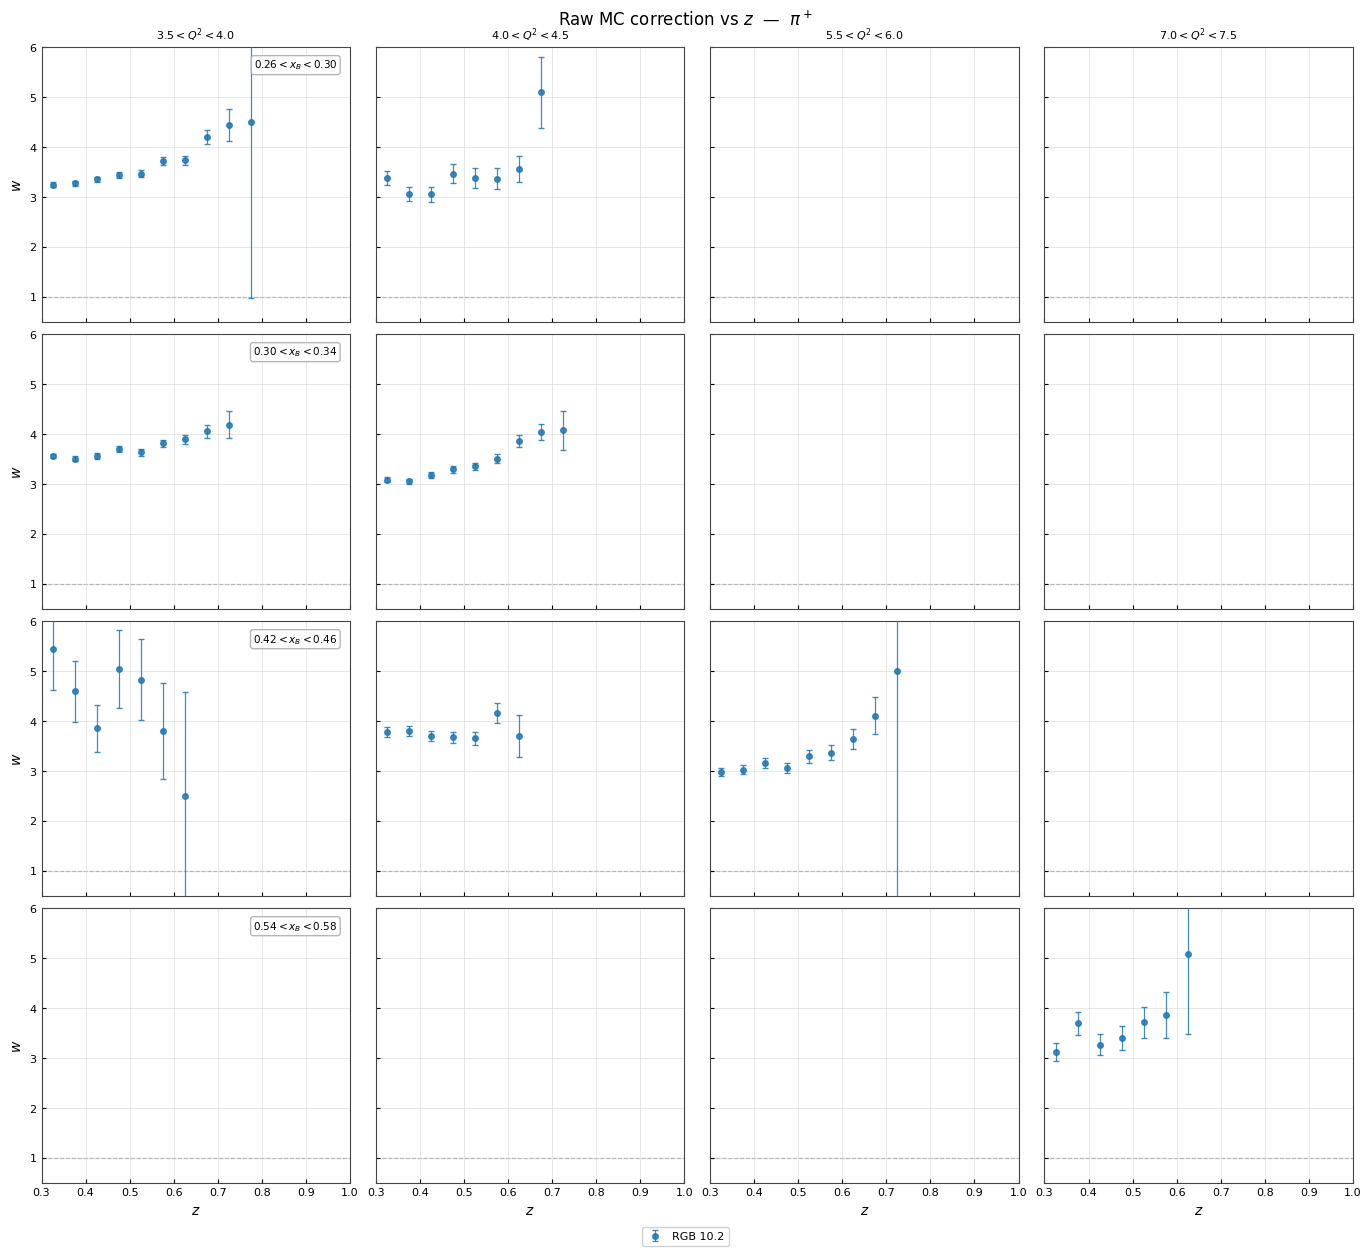

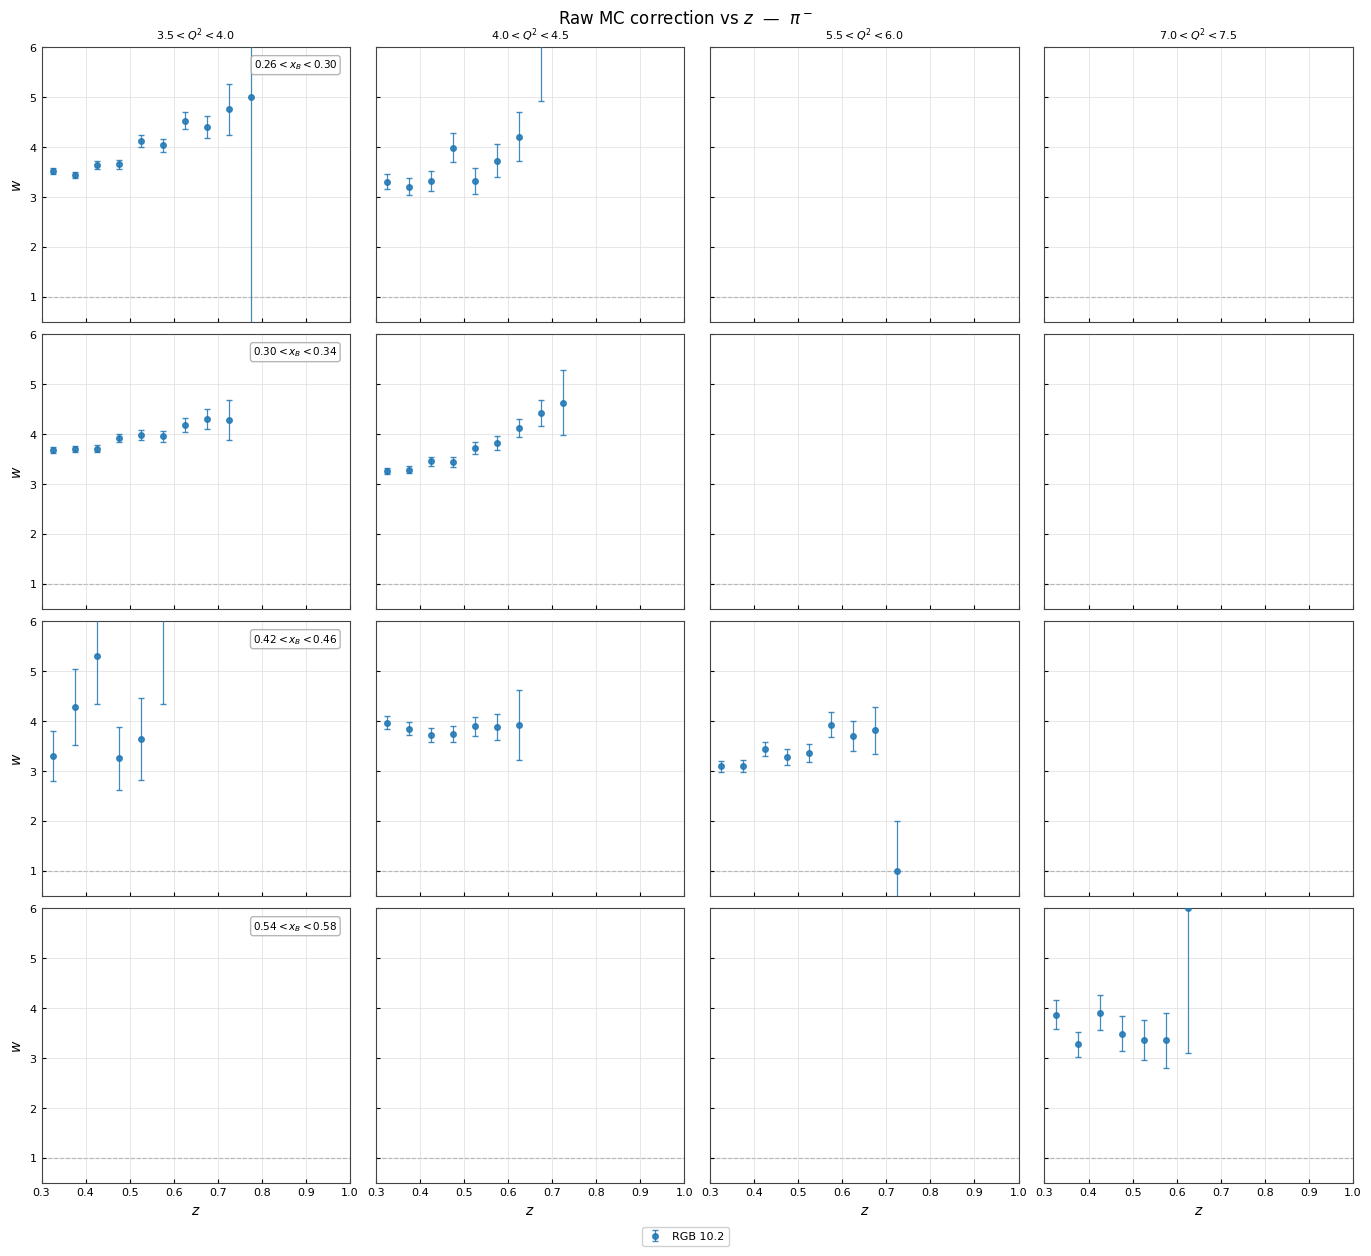

In [226]:
# ── Raw histograms: vs_z  — grid of (xB, Q2) panels ──────────────────────────
n_rows = len(ix_list)
n_cols = len(iq_list)

for sign, sign_lbl in [('P', r'$\pi^+$'), ('M', r'$\pi^-$')]:
    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 3.4, n_rows * 3.0),
        sharex=True, sharey=True, constrained_layout=True
    )
    fig.suptitle(rf'Raw MC correction vs $z$  —  {sign_lbl}', fontsize=12, y=1.01)

    axs = np.atleast_2d(axs)
    if axs.shape == (1, 1) and n_rows * n_cols > 1:
        axs = axs.reshape(n_rows, n_cols)

    for row, ix in enumerate(ix_list):
        for col, iq in enumerate(iq_list):
            ax = axs[row, col]
            _draw_panel_raw(ax, z_centers, sign, ix, iq, None, 'vs_z')
            ax.set_xlim(z_edges[0], z_edges[-1])
            if row == 0:
                ax.set_title(q2_lbl(iq), fontsize=8)
            if col == 0:
                ax.set_ylabel(r'$w$', fontsize=10)
                panel_label(ax, xb_lbl(ix))
            if row == n_rows - 1:
                ax.set_xlabel(LABEL['z'], fontsize=10)

    seen = {}; all_h = []; all_l = []
    for _ax in axs.ravel():
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=min(len(all_h), 6),
               fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.5)
    plt.show()

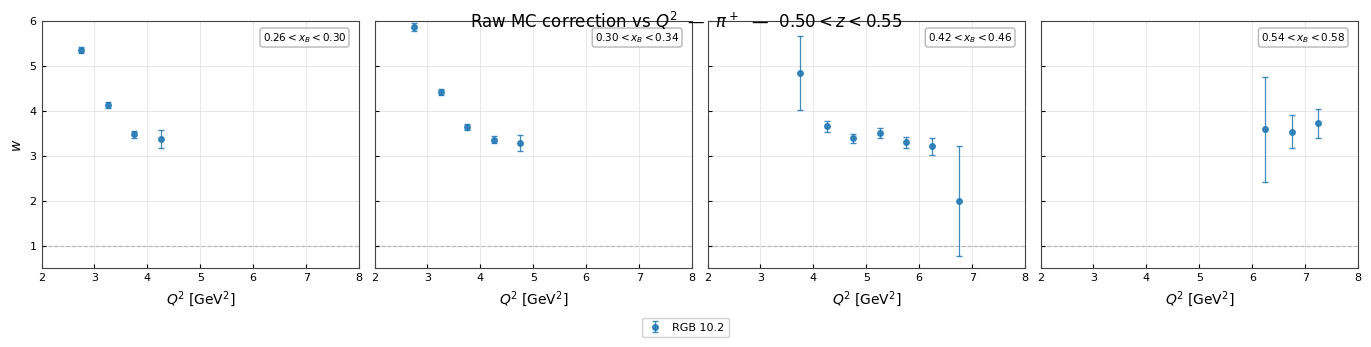

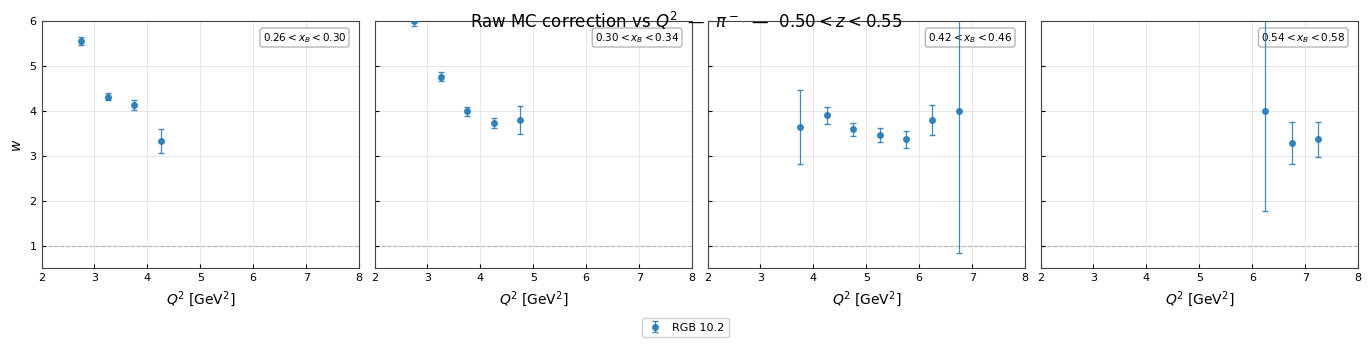

In [227]:
# ── Raw histograms: vs_q2  — grid of xB panels at fixed z bin ─────────────────
ncols = min(4, len(ix_list))
nrows = math.ceil(len(ix_list) / ncols)

for sign, sign_lbl in [('P', r'$\pi^+$'), ('M', r'$\pi^-$')]:
    fig, axs = plt.subplots(
        nrows, ncols, figsize=(ncols * 3.4, nrows * 3.0),
        sharex=True, sharey=True, constrained_layout=True
    )
    fig.suptitle(
        rf'Raw MC correction vs $Q^2$  —  {sign_lbl}  —  {z_lbl(SHOW_Z_BIN)}',
        fontsize=12, y=1.01
    )
    axs_flat = np.array(axs).ravel()

    for pi, ix in enumerate(ix_list):
        ax = axs_flat[pi]
        panel_label(ax, xb_lbl(ix))
        _draw_panel_raw(ax, Q2_centers, sign, ix, None, SHOW_Z_BIN, 'vs_q2')
        ax.set_xlim(Q2_edges[0], Q2_edges[-1])
        if pi % ncols == 0:
            ax.set_ylabel(r'$w$', fontsize=10)
        if pi // ncols == nrows - 1:
            ax.set_xlabel(LABEL['Q2'], fontsize=10)

    for pi in range(len(ix_list), nrows * ncols):
        axs_flat[pi].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:len(ix_list)]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=len(datasets),
               fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.5)
    plt.show()

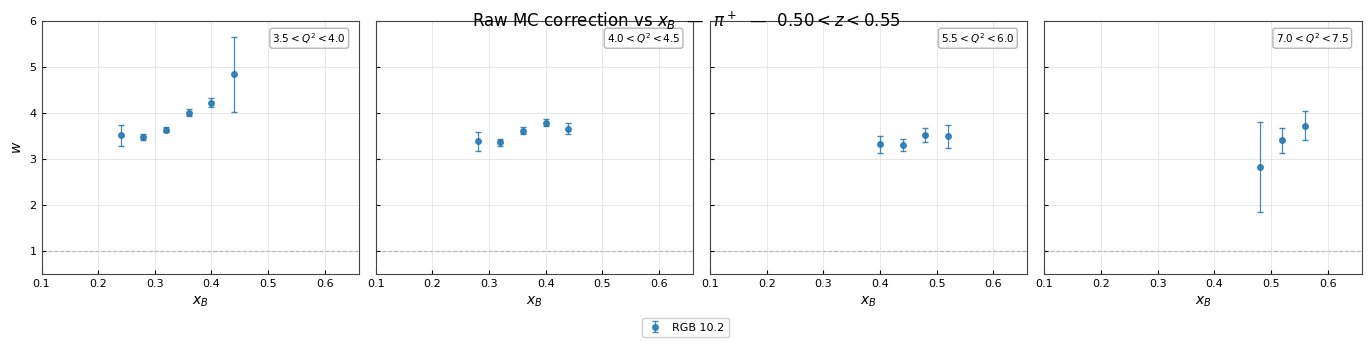

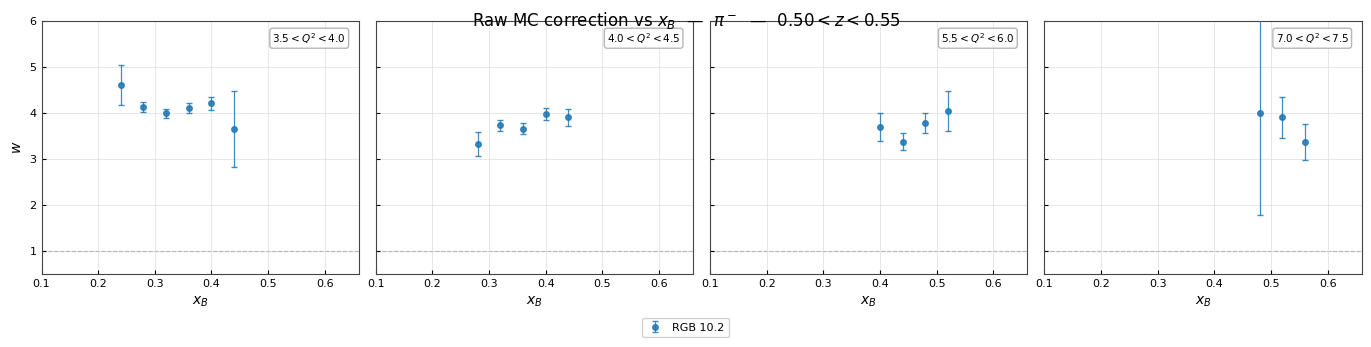

In [228]:
# ── Raw histograms: vs_xB  — grid of Q2 panels at fixed z bin ─────────────────
ncols = min(4, len(iq_list))
nrows = math.ceil(len(iq_list) / ncols)

for sign, sign_lbl in [('P', r'$\pi^+$'), ('M', r'$\pi^-$')]:
    fig, axs = plt.subplots(
        nrows, ncols, figsize=(ncols * 3.4, nrows * 3.0),
        sharex=True, sharey=True, constrained_layout=True
    )
    fig.suptitle(
        rf'Raw MC correction vs $x_B$  —  {sign_lbl}  —  {z_lbl(SHOW_Z_BIN)}',
        fontsize=12, y=1.01
    )
    axs_flat = np.array(axs).ravel()

    for qi, iq in enumerate(iq_list):
        ax = axs_flat[qi]
        panel_label(ax, q2_lbl(iq))
        _draw_panel_raw(ax, xB_centers, sign, None, iq, SHOW_Z_BIN, 'vs_xB')
        ax.set_xlim(xB_edges[0], xB_edges[-1])
        if qi % ncols == 0:
            ax.set_ylabel(r'$w$', fontsize=10)
        if qi // ncols == nrows - 1:
            ax.set_xlabel(LABEL['xB'], fontsize=10)

    for qi in range(len(iq_list), nrows * ncols):
        axs_flat[qi].set_visible(False)

    seen = {}; all_h = []; all_l = []
    for _ax in axs_flat[:len(iq_list)]:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            if _l not in seen:
                seen[_l] = True; all_h.append(_h); all_l.append(_l)
    fig.legend(all_h, all_l, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=len(datasets),
               fontsize=8, frameon=True, columnspacing=0.8, handlelength=1.5)
    plt.show()